In [23]:
import os
import random
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from PIL import Image

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

from sklearn.metrics import confusion_matrix, classification_report
from sklearn.utils.class_weight import compute_class_weight

In [2]:
print("TensorFlow Version:", tf.__version__)

TensorFlow Version: 2.15.0


In [9]:
# Konfigurasi
SEED = 42
IMG_SIZE = (224, 224)
BATCH_SIZE = 32
AUTOTUNE = tf.data.AUTOTUNE
CLASS_NAMES = [
    'Blackheads',
    'Cyst',
    'Papules',
    'Pustules',
    'Whiteheads'
]
NUM_CLASSES = len(CLASS_NAMES)

DATASET_DIR = "AcneDataset"
TRAIN_DIR = os.path.join(DATASET_DIR, "train")
VALID_DIR = os.path.join(DATASET_DIR, "valid")
TEST_DIR  = os.path.join(DATASET_DIR, "test")

tf.random.set_seed(SEED)
np.random.seed(SEED)
random.seed(SEED)

In [10]:
# Struktur Dataset
for split in ['train', 'valid', 'test']:
    split_path = os.path.join(DATASET_DIR, split)
    print(f"\n{split.upper()} Data")  

    total_images = 0
    for class_name in os.listdir(split_path):
        class_path = os.path.join(split_path, class_name)
        if os.path.isdir(class_path):
            num_images = len(os.listdir(class_path))
            total_images += num_images
            print(f"{class_name}: {num_images} images")
    
    print(f"Total: {total_images} images")


TRAIN Data
Blackheads: 735 images
Cyst: 645 images
Papules: 621 images
Pustules: 584 images
Whiteheads: 193 images
Total: 2778 images

VALID Data
Blackheads: 240 images
Cyst: 206 images
Papules: 209 images
Pustules: 217 images
Whiteheads: 49 images
Total: 921 images

TEST Data
Blackheads: 265 images
Cyst: 189 images
Papules: 202 images
Pustules: 205 images
Whiteheads: 57 images
Total: 918 images


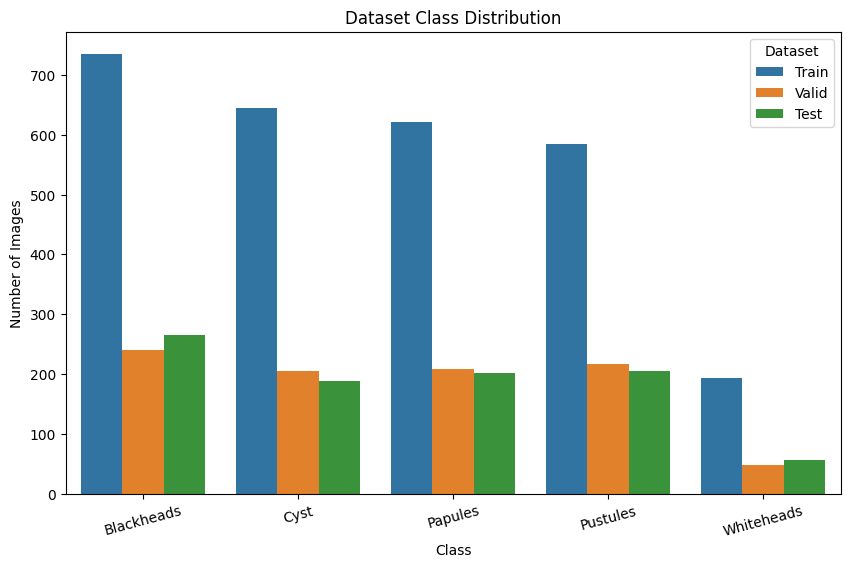

In [22]:
# Distribusi Kelas  
splits = {
    "Train": TRAIN_DIR,
    "Valid": VALID_DIR,
    "Test": TEST_DIR
}

distribution_data = []
for split_name, split_path in splits.items():
    for class_name in CLASS_NAMES:
        class_path = os.path.join(
            split_path,
            class_name
        )
        num_images = len([
            file for file in os.listdir(class_path)
            if file.lower().endswith(
                ('.png', '.jpg', '.jpeg')
            )
        ])
        distribution_data.append({
            "Dataset": split_name,
            "Class": class_name,
            "Count": num_images
        })

distribution_df = pd.DataFrame(distribution_data)
plt.figure(figsize=(10,6))

sns.barplot(
    data=distribution_df,
    x="Class",
    y="Count",
    hue="Dataset"
)

plt.title("Dataset Class Distribution")
plt.xlabel("Class")
plt.ylabel("Number of Images")

plt.xticks(rotation=15)

plt.show()

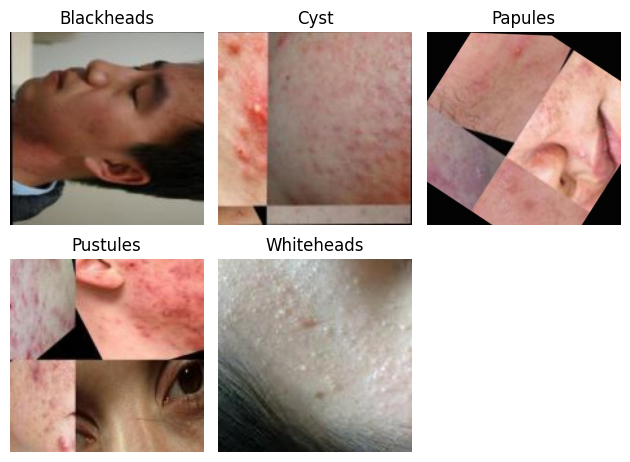

In [21]:
# Visualisasi
for i, class_name in enumerate(CLASS_NAMES):
    class_path = os.path.join(TRAIN_DIR, class_name)
    image_name = random.choice(os.listdir(class_path))
    image_path = os.path.join(class_path, image_name)
    image = Image.open(image_path)
    plt.subplot(2,3,i+1)
    plt.imshow(image)
    plt.title(class_name)
    plt.axis('off')

plt.tight_layout()
plt.show()

In [19]:
print(image.size)

(640, 640)


In [24]:
# Load Dataset
train_dataset = tf.keras.utils.image_dataset_from_directory(
    TRAIN_DIR,
    labels='inferred',
    label_mode='categorical',
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=True,
    seed=SEED
)

valid_dataset = tf.keras.utils.image_dataset_from_directory(
    VALID_DIR,
    labels='inferred',
    label_mode='categorical',
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False
)

test_dataset = tf.keras.utils.image_dataset_from_directory(
    TEST_DIR,
    labels='inferred',
    label_mode='categorical',
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False
)

Found 2778 files belonging to 5 classes.
Found 921 files belonging to 5 classes.
Found 918 files belonging to 5 classes.


In [25]:
class_names = train_dataset.class_names

print("Class Names:")
print(class_names)

Class Names:
['Blackheads', 'Cyst', 'Papules', 'Pustules', 'Whiteheads']


In [28]:
# Augementasi (Sementara Global)
data_augmentation = keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.2),
    layers.RandomZoom(0.2),
    layers.RandomContrast(0.2),
    ], name="augmentation")

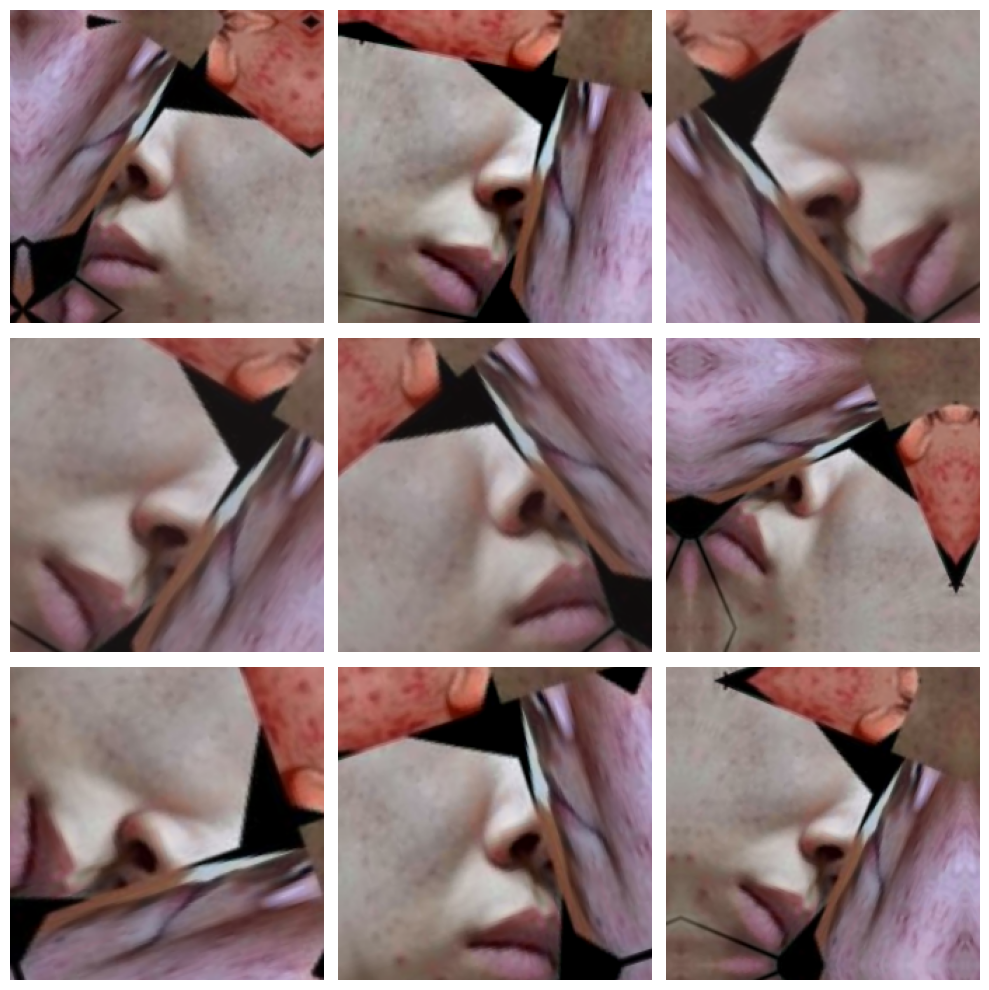

In [29]:
# Visualisasi Augmentasi
for images, labels in train_dataset.take(1):
    sample_image = images[0]
    plt.figure(figsize=(10,10))

    for i in range(9):     
        augmented_image = data_augmentation(
            tf.expand_dims(sample_image, 0)
        )
        plt.subplot(3,3,i+1)
        plt.imshow(
            augmented_image[0].numpy().astype("uint8")
        )
        plt.axis("off")
    
    plt.tight_layout()
    plt.show()

In [30]:
# Normalisasi
normalization_layer = layers.Rescaling(1./255)

In [31]:
# Preprocessing
train_dataset = train_dataset.map(
    lambda x, y: (
        normalization_layer(
            data_augmentation(x, training=True)
        ),
        y
    ),
    num_parallel_calls=AUTOTUNE
)

valid_dataset = valid_dataset.map(
    lambda x, y: (
        normalization_layer(x),
        y
    ),
    num_parallel_calls=AUTOTUNE
)

test_dataset = test_dataset.map(
    lambda x, y: (
        normalization_layer(x),
        y
    ),
    num_parallel_calls=AUTOTUNE
)

In [32]:
# Optimasi
train_dataset = train_dataset.cache().prefetch(
    buffer_size=AUTOTUNE
)

valid_dataset = valid_dataset.cache().prefetch(
    buffer_size=AUTOTUNE
)

test_dataset = test_dataset.cache().prefetch(
    buffer_size=AUTOTUNE
)

In [33]:
# Class Weight 

train_labels = []

for images, labels in train_dataset.unbatch():
    train_labels.append(
        np.argmax(labels.numpy())
    )

train_labels = np.array(train_labels)
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(train_labels),
    y=train_labels
)

class_weights = dict(
    enumerate(class_weights)
)

print("Class Weights:")
print(class_weights)

Class Weights:
{0: 0.7559183673469387, 1: 0.8613953488372093, 2: 0.8946859903381642, 3: 0.9513698630136986, 4: 2.8787564766839377}


In [34]:
# Test Batch 
for images, labels in train_dataset.take(1):    
    print("Image Shape :", images.shape)
    print("Label Shape :", labels.shape)
    print("Min Pixel :", tf.reduce_min(images).numpy())
    print("Max Pixel :", tf.reduce_max(images).numpy())

Image Shape : (32, 224, 224, 3)
Label Shape : (32, 5)
Min Pixel : 0.027882567
Max Pixel : 0.98282266


## Modeling

In [36]:
# Custom Layer
class CustomAttentionLayer(layers.Layer):
    
    def __init__(self):
        super(CustomAttentionLayer, self).__init__()
        # Convolution layer untuk membuat attention map
        self.conv = layers.Conv2D(
            filters=1,
            kernel_size=7,
            padding='same',
            activation='sigmoid'
        )

    def call(self, inputs):
        # Membuat attention map
        attention_map = self.conv(inputs)
        # Mengalikan attention map dengan feature map input
        return inputs * attention_map

In [37]:
# Custom Callback
class CustomTrainingCallback:
    
    def __init__(self):        
        self.best_val_acc = 0
        
    def update(self, current_val_acc):
        if current_val_acc > self.best_val_acc:
            self.best_val_acc = current_val_acc
        
            print(
                f"\nNew Best Validation Accuracy:"
                f" {current_val_acc:.4f}"
            )

In [38]:
# Baseline CNN Model 
inputs = keras.Input(
    shape=(224, 224, 3)
)

# Block 1
x = layers.Conv2D(
    32,
    (3,3),
    activation='relu',
    padding='same'
)(inputs)

x = layers.BatchNormalization()(x)
x = layers.MaxPooling2D()(x)
x = CustomAttentionLayer()(x)

# Block 2
x = layers.Conv2D(
    64,
    (3,3),
    activation='relu',
    padding='same'
)(x)
x = layers.BatchNormalization()(x)
x = layers.MaxPooling2D()(x)

# Block 3
x = layers.Conv2D(
    128,
    (3,3),
    activation='relu',
    padding='same'
)(x)

x = layers.BatchNormalization()(x)
x = layers.MaxPooling2D()(x)
x = layers.Dropout(0.3)(x)
x = layers.GlobalAveragePooling2D()(x)
# Fully connected layer
x = layers.Dense(
    128,
    activation='relu'
)(x)
x = layers.Dropout(0.3)(x)

# Output layer
outputs = layers.Dense(
    NUM_CLASSES,
    activation='softmax'
)(x)

In [39]:
# Membuat BAseline Model
baseline_model = keras.Model(
    inputs,
    outputs,
    name="Baseline_CNN"
)
baseline_model.summary()

Model: "Baseline_CNN"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_2 (InputLayer)        [(None, 224, 224, 3)]     0         
                                                                 
 conv2d_1 (Conv2D)           (None, 224, 224, 32)      896       
                                                                 
 batch_normalization_1 (Bat  (None, 224, 224, 32)      128       
 chNormalization)                                                
                                                                 
 max_pooling2d_1 (MaxPoolin  (None, 112, 112, 32)      0         
 g2D)                                                            
                                                                 
 custom_attention_layer (Cu  (None, 112, 112, 32)      1569      
 stomAttentionLayer)                                             
                                                      

In [40]:
# Loss Function
loss_fn = keras.losses.CategoricalCrossentropy(
    label_smoothing=0.1
)

In [41]:
# Adam optimizer
optimizer = keras.optimizers.Adam(
    learning_rate=0.001
)

In [42]:
# Eval
train_accuracy = keras.metrics.CategoricalAccuracy()
valid_accuracy = keras.metrics.CategoricalAccuracy()
train_loss_metric = keras.metrics.Mean()
valid_loss_metric = keras.metrics.Mean()

In [43]:
# TensorBoard
log_dir = "logs/baseline"

summary_writer = tf.summary.create_file_writer(
    log_dir
)

### Training 

In [47]:
EPOCHS = 20
training_callback = CustomTrainingCallback()

In [48]:
@tf.function
def train_step(images, labels):
    with tf.GradientTape() as tape:
        
        # Forward pass
        predictions = baseline_model(
            images,
            training=True
        )
        
        # Compute loss
        loss = loss_fn(
            labels,
            predictions
        )
    
    # Compute gradient
    gradients = tape.gradient(
        loss,
        baseline_model.trainable_variables
    )
    
    # Update weights
    optimizer.apply_gradients(
        zip(
            gradients,
            baseline_model.trainable_variables
        )
    )
    
    # Update metrics
    train_accuracy.update_state(
        labels,
        predictions
    )
    
    train_loss_metric.update_state(loss)
    return loss

In [49]:
@tf.function
def valid_step(images, labels):
    
    # Forward pass 
    predictions = baseline_model(
        images,
        training=False
    )
    
    # Compute loss
    loss = loss_fn(
        labels,
        predictions
    )
    
    # Update metrics
    valid_accuracy.update_state(
        labels,
        predictions
    )
    
    valid_loss_metric.update_state(loss)
    return loss

In [51]:
# Train loop
best_val_acc = 0

for epoch in range(EPOCHS):
    
    print(f"\nEpoch {epoch+1}/{EPOCHS}")
        
    train_accuracy.reset_state()
    valid_accuracy.reset_state()
    train_loss_metric.reset_state()
    valid_loss_metric.reset_state()
    
    # Train
    for images, labels in train_dataset:
        
        train_step(images, labels)
    # Val
    for images, labels in valid_dataset:
        
        valid_step(images, labels)
    
    train_acc = train_accuracy.result()
    valid_acc = valid_accuracy.result()
    train_loss = train_loss_metric.result()
    valid_loss = valid_loss_metric.result()
    
    print(
        f"Train Loss : {train_loss:.4f} | "
        f"Train Acc : {train_acc:.4f}"
    ) 
    print(
        f"Valid Loss : {valid_loss:.4f} | "
        f"Valid Acc : {valid_acc:.4f}"
    )
    
    # callback
    training_callback.update(valid_acc)
    
    # Save Model
    if valid_acc > best_val_acc:
        best_val_acc = valid_acc
        baseline_model.save(
            "saved_models/baseline_best.keras"
        )
        print("Best model saved.")
    
    #Log
    with summary_writer.as_default():
        tf.summary.scalar(
            'train_loss',
            train_loss,
            step=epoch
        )
        tf.summary.scalar(
            'valid_loss',
            valid_loss,
            step=epoch
        )
        tf.summary.scalar(
            'train_accuracy',
            train_acc,
            step=epoch
        )
        tf.summary.scalar(
            'valid_accuracy',
            valid_acc,
            step=epoch
        )


Epoch 1/20
Train Loss : 1.4146 | Train Acc : 0.4050
Valid Loss : 1.8602 | Valid Acc : 0.2606

New Best Validation Accuracy: 0.2606
Best model saved.

Epoch 2/20
Train Loss : 1.3741 | Train Acc : 0.4154
Valid Loss : 2.0696 | Valid Acc : 0.2584

Epoch 3/20
Train Loss : 1.3437 | Train Acc : 0.4381
Valid Loss : 2.0094 | Valid Acc : 0.2780

New Best Validation Accuracy: 0.2780
Best model saved.

Epoch 4/20
Train Loss : 1.3138 | Train Acc : 0.4608
Valid Loss : 1.7968 | Valid Acc : 0.2921

New Best Validation Accuracy: 0.2921
Best model saved.

Epoch 5/20
Train Loss : 1.2968 | Train Acc : 0.4766
Valid Loss : 1.7047 | Valid Acc : 0.2942

New Best Validation Accuracy: 0.2942
Best model saved.

Epoch 6/20
Train Loss : 1.2750 | Train Acc : 0.5014
Valid Loss : 1.5685 | Valid Acc : 0.3279

New Best Validation Accuracy: 0.3279
Best model saved.

Epoch 7/20
Train Loss : 1.2507 | Train Acc : 0.5241
Valid Loss : 1.3656 | Valid Acc : 0.4267

New Best Validation Accuracy: 0.4267
Best model saved.

Epoch